# T5 Prefix Tuning으로 영어 금융 감성 분석

T5는 번역·요약·분류처럼 서로 다른 NLP 작업을 모두 `입력 text → 출력 text` 생성 문제로 통일하는 Encoder–Decoder 모델이다. 이 노트북에서는 T5가 문장을 읽고 label 문자열을 생성하는 원리를 먼저 확인한 뒤, 영어 Financial PhraseBank를 `negative`, `neutral`, `positive`로 분류하도록 Prefix Tuning한다.

전체 모델을 다시 학습하는 대신 작은 PEFT adapter만 갱신하므로 제한된 GPU에서도 실습할 수 있다. 각 단계의 출력 객체는 다음 단계의 입력으로 이어지며, 학습한 adapter로 평가와 추론을 마친 뒤 결과를 저장한다.


## T5란

T5는 **Text-to-Text Transfer Transformer**의 약자이며, Google 연구팀이 공개한 Encoder–Decoder 구조의 사전학습 언어 모델이다. 핵심 아이디어는 분류·번역·요약·질의응답을 서로 다른 전용 모델로 처리하지 않고, 모든 작업을 **text를 입력받아 text를 생성하는 문제**로 표현하는 것이다.

예를 들어 일반 분류 모델은 `positive`에 해당하는 class 번호를 출력하지만, T5는 label 자체를 문자열로 생성한다.

- 번역: `translate English to French: I love you` → `Je t'aime`
- 요약: `summarize: 긴 문서` → `짧은 요약문`
- 감성 분류: `sentiment: The profit increased.` → `positive`

![T5의 text-to-text 통합 구조](https://1.bp.blogspot.com/-o4oiOExxq1s/Xk26XPC3haI/AAAAAAAAFU8/NBlvOWB84L0PTYy9TzZBaLf6fwPGJTR0QCLcBGAsYHQ/s640/image3.gif)

그림은 서로 다른 작업의 입력을 왼쪽에서 text로 전달하고, 가운데의 같은 T5가 오른쪽의 target text를 생성하는 구조를 나타낸다. 색이 같은 입력과 출력이 하나의 작업 쌍이며, task마다 별도 출력 layer를 만드는 대신 입력 문자열의 task prefix로 작업을 구분한다.

출처: [Raffel et al., *Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transformer*, Figure 1](https://www.jmlr.org/papers/volume21/20-074/20-074.pdf#page=3) (CC BY 4.0)

이 방식의 장점은 작업이 달라도 Tokenizer, Encoder–Decoder, token 단위 Cross Entropy loss와 `generate()`라는 같은 학습·추론 인터페이스를 재사용할 수 있다는 점이다. 이 노트북에서는 약 2.2억 파라미터의 `t5-base`로 여러 작업의 생성 방식을 먼저 확인하고, 약 7.7억 파라미터의 `t5-large`에는 금융 감성용 Prefix adapter를 연결한다.

T5는 대규모 영어 corpus인 C4를 이용해 사전학습되었다. 사전학습 때는 문장의 일부 구간을 `<extra_id_0>` 같은 sentinel token으로 가리고, Decoder가 빠진 구간을 생성하도록 학습한다. 이렇게 일반 언어 구조를 먼저 익힌 모델을 금융 감성 데이터에 맞게 전이학습한다.

### 이번 실습에서 사용하는 Hugging Face 모델

- T5 동작 확인: [google-t5/t5-base](https://huggingface.co/google-t5/t5-base)
- 금융 감성 Prefix Tuning: [google-t5/t5-large](https://huggingface.co/google-t5/t5-large)

두 주소는 model card, 설정과 파일을 확인하는 공식 Hugging Face 저장소이다. 코드에서는 호환되는 짧은 ID인 `t5-base`, `t5-large`를 사용하며 같은 공개 checkpoint를 내려받는다.

추가 참고 자료: [T5 논문 소개 페이지](https://www.jmlr.org/papers/v21/20-074.html), [Hugging Face T5 문서](https://huggingface.co/docs/transformers/model_doc/t5)


## T5의 Encoder–Decoder 동작 원리

T5는 입력을 이해하는 **Encoder**와 결과를 한 token씩 생성하는 **Decoder**로 나뉜다. Llama처럼 Decoder만 사용하는 모델과 달리, 입력 해석과 출력 생성을 두 부분이 나누어 담당한다.

- **Tokenizer**가 SentencePiece subword 단위로 입력 문자열을 나누고 `input_ids`와 `attention_mask`로 변환한다. `input_ids`는 token 번호이고, `attention_mask`는 실제 token과 padding을 구분한다.
- **Encoder**의 양방향 Self-Attention이 입력 전체를 함께 읽고 각 token의 문맥 표현을 만든다.
- **Decoder**는 지금까지 생성한 token을 Masked Self-Attention으로 읽고, Cross-Attention으로 Encoder의 문맥 표현을 참고한다.
- Decoder가 다음 token의 확률을 계산하고 하나를 선택하는 과정을 종료 token인 EOS가 나올 때까지 반복한다.
- **Tokenizer**가 생성된 token ID를 다시 사람이 읽을 수 있는 문자열로 복원한다.

전체 흐름은 다음과 같다.

`입력 문자열 → Tokenizer → Encoder 문맥 → Decoder의 다음 token 생성 반복 → 출력 문자열`

학습할 때는 정답 문자열을 `labels`로 전달한다. Transformers의 T5 구현은 label을 한 칸 오른쪽으로 이동한 Decoder 입력을 내부에서 만들고, 각 위치에서 정답 token을 맞히도록 loss를 계산한다.

이처럼 정답의 이전 token을 보면서 다음 token을 학습하는 방식을 **Teacher Forcing**이라고 한다. 추론할 때는 정답이 없으므로 `generate()`가 모델이 방금 생성한 token을 다시 입력으로 사용한다.


## 환경설정과 버전 확인

Python 3.12·PyTorch 2.8 RunPod 환경에 Prefix Tuning 의존성을 한 번 설치한다. Financial PhraseBank dataset script를 유지하기 위해 `datasets==3.6.0`을 사용하고 실제 kernel의 Transformers·Datasets·PEFT·fsspec 버전을 출력한다.

PyCharm에서는 SSH interpreter 등록과 별도로 RunPod의 **외부 Jupyter server와 kernel**을 선택해야 이후 학습 셀이 원격 GPU에서 실행된다. 연결 과정은 [RunPod SSH·PyCharm 연결](../10_sllm/02_runpod_ssh_pycharm.ipynb)을 참고한다.

Pod 환경변수에 `HF_HOME=/workspace/cache/huggingface`를 지정하면 T5 model과 Dataset cache를 Network Volume에 유지할 수 있다. 공개 파일 다운로드에는 `HF_TOKEN`이 필요하지 않으며, token은 마지막의 선택적 Hub 업로드에만 사용한다. Edit Pod에서 환경변수를 바꿨다면 Pod를 재시작하고 외부 Jupyter server에 다시 연결한다. token 발급과 RunPod Secret 연결은 [Hugging Face 모델·환경변수 준비](../10_sllm/03_sllm.ipynb)를 참고한다.


In [2]:
%pip install -U "transformers==4.56.2" "accelerate>=1,<2" "peft==0.18.0" "datasets==3.6.0" python-dotenv scikit-learn fsspec hf_transfer

import datasets
import fsspec
import peft
import transformers

print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("peft:", peft.__version__)
print("fsspec:", fsspec.__version__)

import torch
import torchvision

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("CUDA available?:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


  Using cached transformers-4.56.2-py3-none-any.whl.metadata (40 kB)
  Using cached accelerate-1.14.0-py3-none-any.whl.metadata (19 kB)
  Using cached peft-0.18.0-py3-none-any.whl.metadata (14 kB)
  Using cached datasets-3.6.0-py3-none-any.whl.metadata (19 kB)
  Using cached python_dotenv-1.2.3-py3-none-any.whl.metadata (29 kB)
  Using cached scikit_learn-1.9.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached fsspec-2026.7.0-py3-none-any.whl.metadata (10 kB)
  Using cached hf_transfer-0.1.9-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (1.7 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached regex-2026.7.19-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (40 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.3 kB)
  Using cached safetensors-0.8.0-cp310-abi3-manylinux_2_17_x86_64.manylinux20

## T5 사전학습 모델과 다섯 가지 text-to-text 작업

`AutoTokenizer`는 문자열을 T5가 계산할 token ID로 바꾸고, `AutoModelForSeq2SeqLM`은 Encoder–Decoder 구조와 text 생성용 language modeling head를 함께 불러온다. `t5_task()`는 `문자열 → token ID → generate() → 문자열` 흐름을 하나의 함수로 묶는다.

번역·문법 판별·질의응답·요약·감성 분류를 같은 함수로 실행하되, 입력 앞의 실제 task prefix만 바뀐다는 점을 확인한다. T5가 숫자 class가 아니라 결과 text를 생성한다는 점이 뒤의 금융 감성 학습과 연결된다.

T5-base는 공개 모델이므로 `HF_TOKEN` 없이 내려받을 수 있다. 첫 실행에는 인터넷 연결과 cache 공간이 필요하지만 이 단계는 CPU에서 실행되므로 GPU는 아직 필요하지 않다.


In [3]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_id = 't5-base'
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForSeq2SeqLM.from_pretrained(model_id, device_map="auto")

def t5_task(prompt: str) -> str:
    input_ids = tokenizer.encode(prompt, return_tensors='pt')

    generated_ids = model.generate(input_ids.to(model.device))

    decoded_text = tokenizer.decode(
        generated_ids[0].detach().cpu(),
        skip_special_tokens=True,
    )
    return decoded_text

print('번역:', t5_task('translate English to French: I love you'))

print('문법 판별:', t5_task('cola sentence: I bought much fruit'))

print('질의응답:', t5_task('question: Which is the highest mountain in the world?'))

long_text = '''
The t5 library serves primarily as code for reproducing the experiments in Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transformer. In the paper, we demonstrate how to achieve state-of-the-art results on multiple NLP tasks using a text-to-text transformer pre-trained on a large text corpus.
The bulk of the code in this repository is used for loading, preprocessing, mixing, and evaluating datasets. It also provides a way to fine-tune the pre-trained models released alongside the publication.
The t5 library can be used for future model development by providing useful modules for training and fine-tuning (potentially huge) models on mixtures of text-to-text tasks.
'''
print('요약:', t5_task(f'summarize: {long_text}'))

print('감성 분류:', t5_task('sst2 sentence: I am very happy today'))


번역: Je vous aime
문법 판별: unacceptable
질의응답: Mount Everest
요약: the t5 library is used for reproducing the experiments in Exploring the Limits of Transfer
감성 분류: positive


## T5의 task prefix와 Prefix Tuning은 다르다

T5 문맥에서 `prefix`라는 말은 두 가지 의미로 사용되므로 구분해야 한다.

### T5 task prefix

`summarize:`처럼 입력 앞에 직접 작성하는 실제 문자열이다. 수행할 작업을 알려 주며 Tokenizer를 거쳐 `input_ids`에 포함된다. 앞의 다섯 가지 작업 실습에서 확인한다.

### PEFT Prefix Tuning

`num_virtual_tokens=20`으로 만드는 학습 가능한 연속 벡터이다. 문자열이나 `input_ids`에 직접 붙이지 않고 PEFT가 모델 내부 Attention에 연결한다.

금융 감성 실습은 한 가지 작업만 학습하므로 `sentiment:` 없이 원문 문장만 사용한다. 학습과 추론에서 이 입력 형식을 동일하게 유지한다.


## Prefix Tuning이란

Prefix Tuning은 사전학습 모델의 기존 가중치를 고정하고, 각 Transformer layer의 Attention이 참고할 작은 **task 전용 prefix vector**만 학습하는 PEFT 방법이다.

<img src="https://miro.medium.com/v2/resize:fit:932/1*n60OiJxF37BRmWiaL1sjTg.jpeg" width="700" alt="전체 Fine-tuning과 Prefix Tuning 비교"/>

그림의 위쪽 Fine-tuning은 task마다 Transformer 전체를 갱신하고 전체 모델 사본을 저장한다. 아래쪽 Prefix Tuning은 회색 pretrained Transformer를 고정한 채, 왼쪽의 작은 분홍색 prefix만 task별로 학습·저장한다. 원 논문은 GPT-2와 BART를 실험 대상으로 사용하지만, 이 노트북에서는 같은 원리를 PEFT가 T5의 Attention에 적용한다.

출처: [Li and Liang, *Prefix-Tuning: Optimizing Continuous Prompts for Generation*, Figure 1](https://aclanthology.org/2021.acl-long.353/)

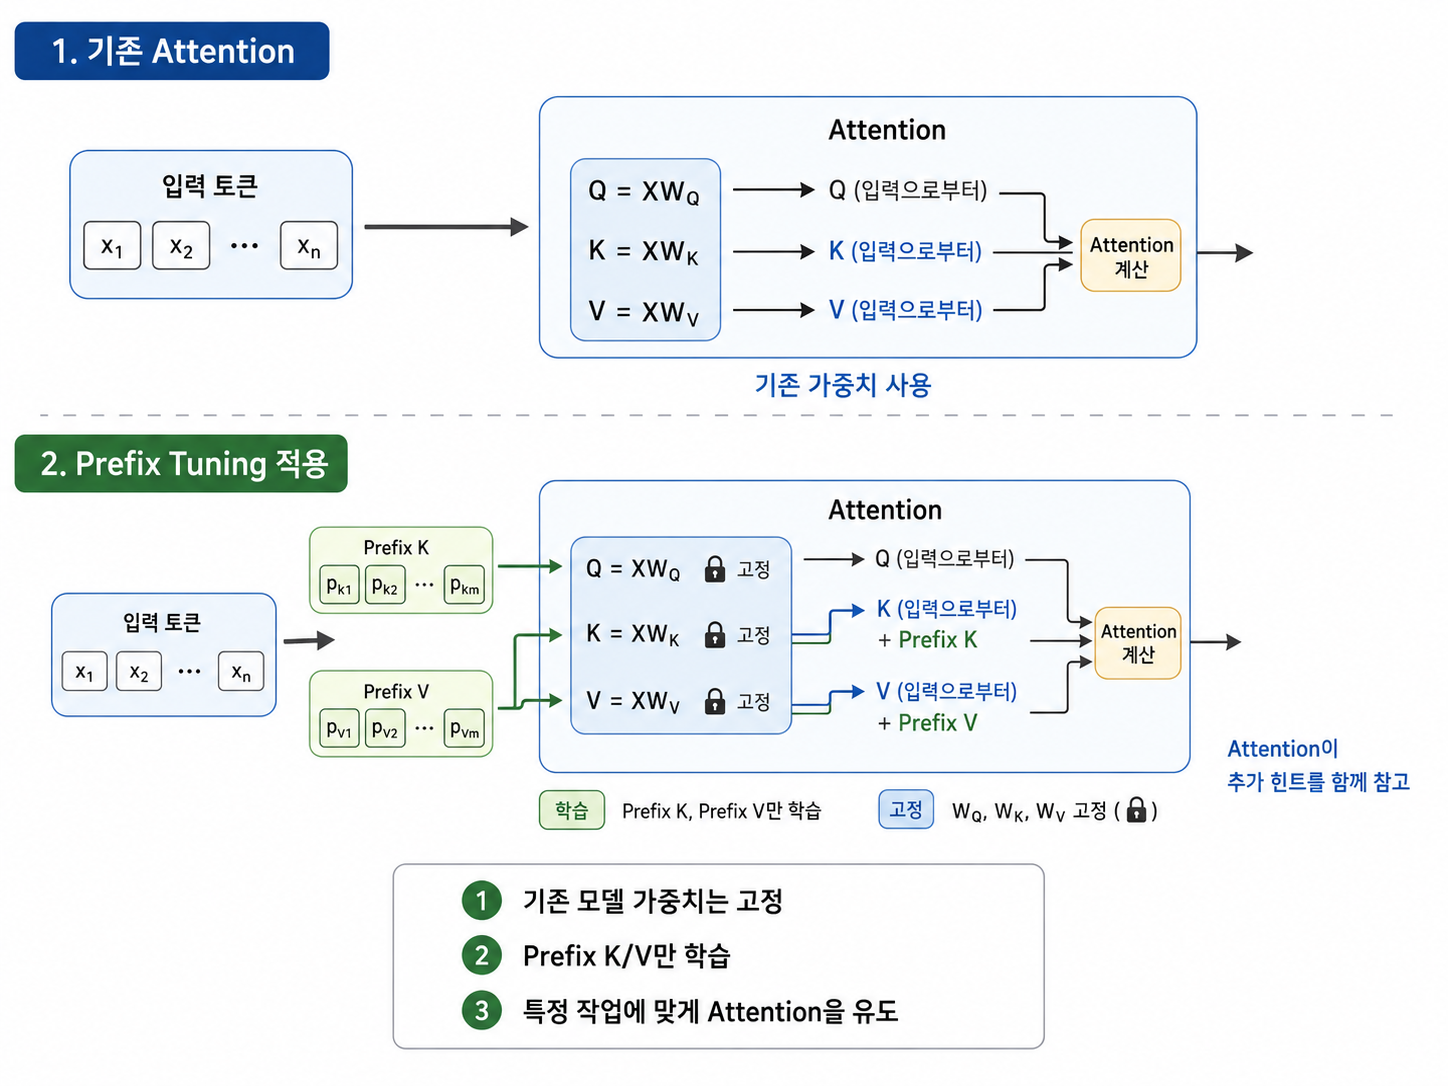

이름 때문에 입력 문장 앞에 사람이 읽을 수 있는 단어를 붙이는 것으로 오해하기 쉽지만, 여기서 `virtual token`은 Dataset 문자열에 추가하는 실제 text token이 아니라 gradient로 학습되는 연속 벡터이다.

Attention이 원래 입력에서 만든 Query `Q`로 Key `K`와 Value `V`를 조회한다면, Prefix Tuning은 학습 가능한 `K_prefix`, `V_prefix`를 앞에 붙인다.

$$
K'=[K_{prefix};K], \qquad V'=[V_{prefix};V]
$$

$$
Attention(Q,K',V')
$$

따라서 입력 token은 고정된 T5를 통과하면서 각 layer에서 task 전용 prefix를 추가 문맥처럼 참고한다. 역전파에서는 T5의 원래 가중치는 바뀌지 않고 prefix vector만 갱신된다. 추론할 때도 `get_peft_model()`이 prefix를 내부적으로 연결하므로 사용자가 입력 문장 앞에 20개의 단어나 token을 직접 붙이지 않는다.

현재 실습의 흐름은 다음과 같다.

`금융 문장 → 고정된 T5-large + 학습 가능한 prefix → negative·neutral·positive`

- **왜 사용하는가**: task마다 전체 모델 복사본을 저장하는 대신 작은 prefix adapter만 학습·저장·교체할 수 있다.
- **LoRA와의 차이**: LoRA는 선택한 선형층에 더할 저차원 가중치 변화량 `ΔW`를 학습하고, Prefix Tuning은 Attention이 참고할 가상 Key·Value 문맥을 학습한다.
- **이 노트북의 설정**: Financial PhraseBank에 맞춰 가상 token 20개를 학습하고 T5-large가 감성 label 문자열을 생성하게 한다.

참고 자료: [Hugging Face PEFT Prefix Tuning 문서](https://huggingface.co/docs/peft/package_reference/prefix_tuning)


## 영어 금융 감성 데이터와 text label

Financial PhraseBank는 금융 뉴스 문장에 감성을 표시한 Dataset이다. `sentences_allagree` 구성은 모든 annotator가 같은 감성에 동의한 문장만 사용하므로 label 신뢰도는 높지만 전체 데이터 수는 줄어든다.

원본 데이터를 90% 학습과 10% 검증으로 나눈 뒤 숫자 label을 T5 Decoder가 생성할 `negative`, `neutral`, `positive` 문자열로 바꾼다. 변환 전 row의 `sentence`, `label`에 변환 후 `text_label`이 추가되며, 이 문자열은 다음 전처리 셀의 `targets`가 된다.

Financial PhraseBank는 공개 Dataset이므로 다운로드에 `HF_TOKEN`이 필요하지 않다. 최초 실행에서는 Hugging Face Hub 연결과 Dataset cache 공간이 필요하다.


In [4]:
from datasets import load_dataset

dataset = load_dataset(
    'financial_phrasebank',        # Hub Dataset 이름이다.
    'sentences_allagree',          # 모든 annotator가 같은 label에 동의한 구성이다.
    trust_remote_code=True,        # 공식 Dataset loading script의 실행을 허용한다.
)
dataset = dataset['train'].train_test_split(test_size=0.1)
dataset['validation'] = dataset['test']
del dataset['test']
print(dataset)

print(dataset['train'].features['label'].names)
print(dataset['train'][0])  # sentence와 숫자 label을 가진 한 문장을 확인한다.

text_labels = dataset['train'].features['label'].names

dataset = dataset.map(
    lambda x: {'text_label': text_labels[x['label']]}
)
print(dataset['train'][0])


DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 2037
    })
    validation: Dataset({
        features: ['sentence', 'label'],
        num_rows: 227
    })
})
['negative', 'neutral', 'positive']
{'sentence': 'Finnish Bore that is owned by the Rettig family has grown recently through the acquisition of smaller shipping companies .', 'label': 2}


Map:   0%|          | 0/2037 [00:00<?, ? examples/s]

Map:   0%|          | 0/227 [00:00<?, ? examples/s]

{'sentence': 'Finnish Bore that is owned by the Rettig family has grown recently through the acquisition of smaller shipping companies .', 'label': 2, 'text_label': 'positive'}


## Tokenizer와 전체 데이터 전처리

T5-large Tokenizer로 금융 문장은 최대 128 token의 Encoder 입력으로, 감성 문자열은 최대 2 token의 Decoder 정답으로 바꾼다. 반환되는 핵심 값의 역할은 다음과 같다.

- `input_ids`: 금융 문장을 숫자 token ID로 바꾼 값이다. Encoder가 읽는다.
- `attention_mask`: 실제 token은 `1`, padding은 `0`으로 표시해 Attention이 빈 자리를 무시하게 한다.
- `labels`: Decoder가 맞혀야 하는 감성 문자열의 token ID이다. Transformers가 Decoder 입력과 loss를 만드는 데 사용한다.

`labels`의 padding은 `-100`으로 바꾼다. PyTorch Cross Entropy loss가 `-100` 위치를 무시하므로 길이를 맞추기 위한 PAD token은 오답으로 계산되지 않는다. `Dataset.map()`이 이 변환을 전체 split에 적용한 결과는 다음 DataLoader의 입력이 된다.


In [5]:
from transformers import AutoTokenizer

pretrained_model_id = 't5-large'

tokenizer = AutoTokenizer.from_pretrained(pretrained_model_id)

def preprocess_fn(examples: dict) -> dict:
    inputs = examples['sentence']
    targets = examples['text_label']

    model_inputs = tokenizer(
        inputs,                    # batched=True이므로 여러 sentence가 list로 들어온다.
        max_length=128,            # Encoder가 받을 token 수의 상한이다.
        padding='max_length',      # 짧은 문장은 PAD를 채워 길이 128로 맞춘다.
        truncation=True,           # 128 token을 넘는 문장은 뒤를 자른다.
        return_tensors='pt',       # 결과를 PyTorch tensor로 반환한다.
    )

    labels = tokenizer(
        targets,                   # negative·neutral·positive 문자열이다.
        max_length=2,              # 감성 label token과 문장 끝 EOS token을 담는다.
        padding='max_length',      # label도 batch에서 같은 길이로 맞춘다.
        truncation=True,           # 길이가 2를 넘으면 뒤 token을 자른다.
        return_tensors='pt',
    )['input_ids']


    # Cross Entropy loss는
    # ignore_index=-100 위치를 계산에서 제외하므로 PAD는 학습 정답이 되지 않는다.
    labels[labels == tokenizer.pad_token_id] = -100
    model_inputs['labels'] = labels

    return model_inputs

sample_batch = preprocess_fn(dataset['train'][:2])
print('sample shapes:', {key: tuple(value.shape) for key, value in sample_batch.items()})

preprocessed_dataset = dataset.map(
    preprocess_fn,                                  # 각 batch에 적용할 변환 함수이다.
    batched=True,                                   # 한 번에 여러 row를 함수에 전달한다.
    remove_columns=dataset['train'].column_names,   # sentence·label·text_label 원본 column을 제거한다.
)

print(preprocessed_dataset['train'][0].keys())


sample shapes: {'input_ids': (2, 128), 'attention_mask': (2, 128), 'labels': (2, 2)}


Map:   0%|          | 0/2037 [00:00<?, ? examples/s]

Map:   0%|          | 0/227 [00:00<?, ? examples/s]

dict_keys(['input_ids', 'attention_mask', 'labels'])


## 학습·검증 DataLoader

전처리된 두 split을 batch size 8의 DataLoader로 묶는다. DataLoader는 Dataset에서 row를 8개씩 꺼내 반복 가능한 batch를 만들고, `default_data_collator`는 각 row의 `input_ids`, `attention_mask`, `labels`를 key별 PyTorch tensor로 쌓는다. 이미 고정 길이 padding을 마쳤으므로 이 단계의 collator는 새로 padding하기보다 같은 길이 값을 batch 축으로 결합한다.

학습 loader는 epoch마다 순서를 섞어 특정 데이터 순서에 치우치지 않게 하고, 검증 loader는 정답과 예측의 순서를 맞추기 위해 섞지 않는다. 두 loader는 이후 학습·검증 loop에서 한 batch씩 소비된다.


In [6]:
from torch.utils.data import DataLoader
from transformers import default_data_collator

batch_size = 8

train_dataset = preprocessed_dataset['train']
val_dataset = preprocessed_dataset['validation']

train_dataloader = DataLoader(
    train_dataset,                         # 반복해서 꺼낼 학습 Dataset이다.
    collate_fn=default_data_collator,      # row 목록을 key별 PyTorch tensor로 묶는다.
    batch_size=batch_size,                 # 한 batch에 8개 row를 넣는다.
    shuffle=True,                          # epoch마다 학습 순서를 섞어 순서 편향을 줄인다.
)
val_dataloader = DataLoader(
    val_dataset,                           # 반복해서 꺼낼 검증 Dataset이다.
    collate_fn=default_data_collator,
    batch_size=batch_size,
    shuffle=False,
)


## T5-large와 Prefix Tuning adapter

T5-large를 GPU에 적재하고 seq2seq용 가상 토큰 20개의 Prefix 설정을 만든다. `get_peft_model()`로 adapter를 결합한 뒤 전체 가중치 중 실제 학습되는 파라미터 수와 비율을 출력한다.

현재 설정처럼 `prefix_projection=False`인 기본값을 사용할 때, `PrefixEncoder`가 직접 학습하는 embedding 파라미터 수는 다음과 같이 계산된다.

$$
20 \times 2 \times 24 \times 1024 = 983{,}040
$$

여기서 `20`은 가상 token 수, `2`는 Attention의 Key와 Value, `24`는 PEFT가 T5-large 설정에서 사용하는 layer 수, `1024`는 각 vector의 차원이다. 따라서 `print_trainable_parameters()`에는 전체 T5-large가 아니라 약 98만 개의 prefix 파라미터만 학습 대상으로 출력된다. architecture나 `prefix_projection` 설정이 달라지면 이 계산도 달라질 수 있다.

T5-large도 공개 모델이므로 별도 접근 승인이나 `HF_TOKEN` 없이 다운로드할 수 있다. 이 셀부터 RunPod GPU를 실제로 사용하며 Prefix Tuning 학습까지 고려해 16GB 이상, 수업에서는 24GB 이상의 VRAM을 권장한다.


In [7]:
from transformers import AutoModelForSeq2SeqLM
from peft import PrefixTuningConfig, TaskType

model = AutoModelForSeq2SeqLM.from_pretrained(pretrained_model_id, device_map='auto')
print(model.device)

peft_config = PrefixTuningConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,  # T5의 입력 text → 출력 text 생성 작업을 지정한다.
    inference_mode=False,            # prefix parameter를 고정하지 않고 학습 가능하게 만든다.
    num_virtual_tokens=20,           # Attention의 Key·Value로 사용할 연속 벡터 위치 수이다.
)

from peft import get_peft_model

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()


cuda:0
trainable params: 983,040 || all params: 738,651,136 || trainable%: 0.1331


## Prefix Tuning 학습 설정

Optimizer는 전체 `model.parameters()`를 받지만 base T5는 `requires_grad=False`이므로 실제 gradient와 update는 Prefix adapter에만 적용된다. `AdamW`는 gradient로 prefix 값을 갱신하고, linear scheduler는 전체 학습 step 동안 학습률을 점차 낮춘다.

`num_training_steps`는 한 epoch의 batch 수에 epoch 수를 곱한 값이다. 이 셀은 학습에 사용할 객체만 준비하며 아직 GPU 학습은 시작하지 않는다.


In [8]:
import torch.optim as optim
from transformers import get_linear_schedule_with_warmup
from tqdm import tqdm
import torch

optimizer = optim.AdamW(model.parameters(), lr=1e-2)

num_epochs = 5
lr_scheduler = get_linear_schedule_with_warmup(
    optimizer=optimizer,                                      # 학습률을 바꿀 AdamW 객체이다.
    num_warmup_steps=0,                                      # 처음부터 설정 학습률을 사용한다.
    num_training_steps=len(train_dataloader) * num_epochs,   # batch 수 × epoch 수가 전체 update 횟수이다.
)

print('epochs:', num_epochs)
print('steps per epoch:', len(train_dataloader))
print('total training steps:', len(train_dataloader) * num_epochs)


epochs: 5
steps per epoch: 255
total training steps: 1275


## Epoch별 Prefix 학습과 검증

학습 batch에는 `input_ids`, `attention_mask`, `labels`가 함께 들어간다. 세 tensor를 이름에 맞춰 model에 전달하면 Teacher Forcing용 Decoder 입력과 token별 Cross Entropy loss를 내부에서 만들고, `backward() → optimizer.step()` 순서로 Prefix parameter를 갱신한다.

각 epoch 뒤에는 gradient 없이 validation loss를 계산한다. `eval_preds`는 정답 label을 함께 전달한 forward 결과의 token별 logits에서 `argmax`한 값이다. 실제 서비스처럼 정답 없이 연속 생성하는 동작은 뒤의 `model.generate()` 추론 셀에서 확인한다.

Perplexity는 token 예측의 불확실성을 나타내므로 낮을수록 좋다. 다만 세 감성의 실제 분류 품질은 다음 `classification_report()`를 함께 확인해야 한다.


In [9]:
for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for batch in tqdm(train_dataloader, desc=f'train epoch {epoch + 1}'):
        batch = {k: v.to(model.device) for k, v in batch.items()}
        outputs = model(
            input_ids=batch['input_ids'],
            attention_mask=batch['attention_mask'],
            labels=batch['labels'],
        )
        loss = outputs.loss
        total_loss += loss.detach().float()

        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()

    model.eval()
    eval_loss = 0
    eval_preds = []

    for batch in tqdm(val_dataloader, desc=f'valid epoch {epoch + 1}'):
        batch = {k: v.to(model.device) for k, v in batch.items()}
        with torch.no_grad():
            outputs = model(
                input_ids=batch['input_ids'],
                attention_mask=batch['attention_mask'],
                labels=batch['labels'],
            )
        loss = outputs.loss
        eval_loss += loss.detach().float()

        pred = torch.argmax(outputs.logits, dim=-1).detach().cpu().numpy()
        eval_preds.extend(
            tokenizer.batch_decode(pred, skip_special_tokens=True)
        )

    eval_epoch_loss = eval_loss / len(val_dataloader)
    eval_ppl = torch.exp(eval_epoch_loss)
    train_epoch_loss = total_loss / len(train_dataloader)
    train_ppl = torch.exp(train_epoch_loss)
    print(f'{epoch=}: {train_ppl=} {train_epoch_loss=} {eval_ppl=} {eval_epoch_loss=}')


valid epoch 1: 100%|██████████| 29/29 [00:01<00:00, 15.26it/s]


epoch=0: train_ppl=tensor(5.0454, device='cuda:0') train_epoch_loss=tensor(1.6185, device='cuda:0') eval_ppl=tensor(1.0884, device='cuda:0') eval_epoch_loss=tensor(0.0847, device='cuda:0')


valid epoch 2: 100%|██████████| 29/29 [00:01<00:00, 15.18it/s]


epoch=1: train_ppl=tensor(1.1287, device='cuda:0') train_epoch_loss=tensor(0.1211, device='cuda:0') eval_ppl=tensor(1.0742, device='cuda:0') eval_epoch_loss=tensor(0.0716, device='cuda:0')


valid epoch 3: 100%|██████████| 29/29 [00:01<00:00, 15.28it/s]


epoch=2: train_ppl=tensor(1.0960, device='cuda:0') train_epoch_loss=tensor(0.0917, device='cuda:0') eval_ppl=tensor(1.0338, device='cuda:0') eval_epoch_loss=tensor(0.0333, device='cuda:0')


valid epoch 4: 100%|██████████| 29/29 [00:01<00:00, 14.68it/s]


epoch=3: train_ppl=tensor(1.0777, device='cuda:0') train_epoch_loss=tensor(0.0749, device='cuda:0') eval_ppl=tensor(1.0251, device='cuda:0') eval_epoch_loss=tensor(0.0248, device='cuda:0')


valid epoch 5: 100%|██████████| 29/29 [00:01<00:00, 15.10it/s]

epoch=4: train_ppl=tensor(1.0752, device='cuda:0') train_epoch_loss=tensor(0.0725, device='cuda:0') eval_ppl=tensor(1.0234, device='cuda:0') eval_epoch_loss=tensor(0.0231, device='cuda:0')


## 검증 예측과 분류 성능

validation의 정답 감성 문자열과 마지막 epoch의 예측 문자열을 같은 순서로 비교한다. 먼저 열 건을 나란히 출력해 빈 문자열이나 label 이외의 text가 섞이지 않았는지 확인한 뒤 `classification_report()`를 계산한다.

- `precision`은 특정 감성이라고 예측한 것 중 실제로 그 감성이 맞는 비율이다.
- `recall`은 실제 특정 감성 문장 중 모델이 찾아낸 비율이다.
- `F1-score`는 precision과 recall의 조화 평균으로 두 값을 함께 비교한다.
- `accuracy`는 전체 validation 문장 중 정확히 맞힌 비율이다.

loss와 perplexity는 token 예측이 얼마나 확신 있는지 보여 주고, 분류 지표는 최종 감성 문자열이 정답과 얼마나 일치하는지 보여 준다. 두 종류의 결과를 함께 해석해야 한다.


In [10]:
true_labels = dataset['validation']['text_label']
predicted_labels = eval_preds

print('정답 표본:', true_labels[10:20])
print('예측 표본:', predicted_labels[10:20])

from sklearn.metrics import classification_report

print(classification_report(
    true_labels,                                             # 실제 감성 문자열 목록이다.
    predicted_labels,                                        # 모델이 예측한 감성 문자열 목록이다.
    target_names=dataset['train'].features['label'].names,   # 출력 행에 사용할 class 이름이다.
))


정답 표본: ['positive', 'neutral', 'neutral', 'neutral', 'neutral', 'positive', 'neutral', 'neutral', 'positive', 'positive']
예측 표본: ['positive', 'neutral', 'neutral', 'neutral', 'neutral', 'positive', 'neutral', 'neutral', 'positive', 'positive']
              precision    recall  f1-score   support

    negative       0.93      1.00      0.96        26
     neutral       1.00      0.97      0.98       132
    positive       0.96      0.99      0.97        69

    accuracy                           0.98       227
   macro avg       0.96      0.99      0.97       227
weighted avg       0.98      0.98      0.98       227



## 새 금융 문장 추론

평가 loop에서는 정답 `labels`를 전달했지만 실제 추론에는 정답이 없다. `generate()`는 Encoder가 만든 문맥과 학습된 Prefix vector를 참고해 Decoder가 첫 감성 token부터 EOS까지 스스로 생성한다.

새 영어 금융 문장을 Tokenizer로 변환하고 tensor를 T5-large가 있는 GPU로 옮긴 뒤, 생성된 token ID를 감성 문자열로 디코딩한다. 학습 때 금융 문장 앞에 별도 task prefix를 붙이지 않았으므로 추론 입력도 같은 형식의 원문 문장만 사용한다. 시장 증가 문장과 경기 둔화 문장을 실행해 학습에 없던 표현으로 일반화되는지 확인한다.


In [11]:
def sentiment_inference(text: str) -> list[str]:
    inputs = tokenizer(text, return_tensors='pt')

    with torch.no_grad():
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
        print(inputs)

        generated_ids = model.generate(
            input_ids=inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            max_new_tokens=3,                         # 감성 단어와 EOS에 충분한 생성 길이 상한이다.
        )
        print(generated_ids)

        decoded_labels = tokenizer.batch_decode(
            generated_ids.detach().cpu().numpy(),
            skip_special_tokens=True,
        )
        return decoded_labels

positive_news = "The Lithuanian beer market made up 14.41 million liters in January , a rise of 0.8 percent from the year-earlier figure , the Lithuanian Brewers ' Association reporting citing the results from its members ."
print('첫 번째 추론:', sentiment_inference(positive_news))

negative_news = """
The global economy is facing increasing headwinds as disappointing economic indicators and persistent uncertainties weigh heavily on investor sentiment. Recent data from major economies such as the United States, China, and Europe have failed to meet expectations, fueling concerns about a potential economic slowdown. Analysts note that the lackluster performance in key sectors, combined with inconsistent earnings reports, has heightened market volatility and prompted investors to seek safer assets.
"""
print('두 번째 추론:', sentiment_inference(negative_news))


{'input_ids': tensor([[   37, 27620,    29,  6061,   512,   263,    95,  9264,  4853,   770,
             3,  9842,     7,    16,  1762,     3,     6,     3,     9,  3098,
            13,     3, 22384,  1093,    45,     8,   215,    18,  2741,  3299,
          2320,     3,     6,     8, 27620,    29,  3004,  3321,     7,     3,
            31,  2125,  5099,     3, 17994,     8,   772,    45,   165,   724,
             3,     5,     1]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1]], device='cuda:0')}
tensor([[   0, 1465,    3,    5]], device='cuda:0')
첫 번째 추론: ['positive .']
{'input_ids': tensor([[   37,  1252,  2717,    19,  5008,  3094,   819,  5165,     7,    38,
         21497,  1456, 15600,    11, 15803, 30879, 11385,  8672,    30, 12024,
          6493,     5, 17716,   331,    45,   779, 18239,   224,    3

## 로컬 모델 저장

학습이 끝난 Prefix adapter와 Tokenizer를 `/workspace/models` 아래에 저장한다. `model.save_pretrained()`가 저장하는 것은 약 7.7억 개의 T5-large 전체 weight가 아니라 Prefix adapter 설정과 작은 학습 weight이다. 다시 사용할 때는 원래 `t5-large` base model과 이 adapter가 모두 필요하다.

RunPod Network Volume에 생성된 경로와 파일은 다음 Pod나 별도 추론 실습에서 다시 적재할 수 있다. 이 경로는 학습 결과를 보존하지만 앞에서 내려받은 Hugging Face cache 위치까지 바꾸지는 않으므로, model cache도 유지하려면 Pod 환경변수 `HF_HOME`을 `/workspace/cache/huggingface`로 지정한다.


In [12]:
from pathlib import Path

trained_model_dir = Path("/workspace/models/t5-large-prefix-tuned-sentiment-analysis")
trained_model_dir.mkdir(parents=True, exist_ok=True)

tokenizer.save_pretrained(trained_model_dir)
model.save_pretrained(trained_model_dir)
print("saved:", trained_model_dir)


saved: /workspace/models/t5-large-prefix-tuned-sentiment-analysis


## 선택 실습: Hugging Face Hub 업로드

환경변수의 문자열 `HF_TOKEN`을 읽고 `HF_REPO_ID`를 사용자의 실제 `사용자명/저장소명`으로 바꾼다. `load_dotenv()`는 현재 폴더의 `.env`가 있으면 값을 추가로 읽는 함수이고, RunPod Edit Pod에 등록한 환경변수 자체는 이미 Python process에 전달되어 `os.getenv()`가 직접 읽는다.

placeholder나 token이 없으면 업로드 전에 오류를 내며, 값이 준비된 경우 Prefix adapter와 Tokenizer를 같은 Hub 저장소에 올린다. 저장소에는 base T5-large 전체 weight가 포함되지 않으므로 내려받는 쪽에서도 adapter 설정에 기록된 base model을 함께 준비해야 한다. Token에는 해당 사용자 namespace에 model repository를 만들거나 갱신할 수 있는 write 권한이 필요하다.


In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()
HF_TOKEN = os.getenv("HF_TOKEN", "")

if not HF_TOKEN:
    raise ValueError("HF_TOKEN 환경변수를 먼저 설정한다.")

HF_REPO_ID = "dkswjdals4027/t5-large-prefix-tuned-sentiment-analysis2"

if HF_REPO_ID.startswith("사용자명/"):
    raise ValueError("HF_REPO_ID를 자신의 사용자명/저장소명으로 변경한다.")

model.push_to_hub(HF_REPO_ID, token=HF_TOKEN)
tokenizer.push_to_hub(HF_REPO_ID, token=HF_TOKEN)
